# Introduction to 1D pulse acquisition
#### Author: Vineeth Thalakottoor, IE CNRS, LSDRM, CEA, Paris-Saclay
#### Email: vineethfrancis.physics@gmail.com

In [2]:
# Define the source path
SourcePath = "/home/vineeth/Documents/PyORv2/PyOR"

# Add source path
import sys
sys.path.append(SourcePath)

import time
%matplotlib ipympl

# Import PyOR package
from PyOR import *

*****        ***** *****
*   *        *   * *   *
*****  *   * *   * *****
*       * *  *   * * *  
*        *   ***** *  * 
        *               
       *                
Welcome to Python On Resonance (PyOR)

Author: Vineeth Thalakottoor, IE CNRS, LSDRM, CEA, Paris-Saclay

Email: vineethfrancis.physics@gmail.com

"Everybody can simulate Magnetic Resonance"

Imported modules:

* QunS                   (QuantumSystem from PyOR_QuantumSystem)
** Hamiltonian           (from PyOR_Hamiltonian)
** DensityMatrix         (from PyOR_DensityMatrix)
** HardPulse             (from PyOR_HardPulse)
** Basis                 (from PyOR_Basis)
** RelaxationProcess     (from PyOR_Relaxation)
** Evolutions            (from PyOR_Evolution)
** Plotting              (from PyOR_Plotting)
** Spro                  (from PyOR_SignalProcessing)
** constants             (from PyOR_PhysicalConstants)
** gamma                 (from PyOR_Gamma)
* QunObj                 (from PyOR_QuantumObject)
* QuantumLibrary 

In [3]:
# Define the spin system
Spin_list = {"A" : "H1", "B" : "H1"}
QS = QunS(Spin_list,PrintDefault=False)

Spin Operators generated (Quantum Objects)
For particle A: Ax, Ay, Az, Ap, Am
For particle B: Bx, By, Bz, Bp, Bm

To see the matrix form use the attribute .matrix


### Set parameters

In [4]:
QS.Configure(
    # Propagation Space
    PropagationSpace="Hilbert",

    # Master Equation
    MasterEquation="Redfield",

    # Operator basis
    Basis_SpinOperators_Hilbert="Zeeman",

    # Field in T
    B0=9.4,

    # Offset frequencies in Hz
    OFFSET={"A": 10.0, "B": 50.0},

    # J coupling
    Jcouplings=[("A", "B", 5.0)],

    # Initial and final spin temperature
    I_spintemp={"A": 300.0, "B": 300.0},
    F_spintemp={"A": 300.0, "B": 300.0},

    # Relaxation process
    Rprocess="Phenomenological",
    R1=1.0,
    R2=2.0,

    # Evolution parameters
    AcqDT = 0.0001,
    AcqAQ = 5.0,
    OdeMethod = 'DOP853',
    PropagationMethod = "ODE Solver",
    
    #Plotting
    PlotFigureSize = (10,5),
    PlotFontSize = 20
)

Spin Operators generated (Quantum Objects)
For particle A: Ax, Ay, Az, Ap, Am
For particle B: Bx, By, Bz, Bp, Bm

To see the matrix form use the attribute .matrix

Setting derived parameters from dictionaries
-------------------------------------------
OmegaRF   <- OMEGA_RF  : [-2514708003.2000003, -2514708003.2000003] from {'A': -2514708003.2000003, 'B': -2514708003.2000003}
Offset    <- OFFSET    : [10.0, 50.0] from {'A': 10.0, 'B': 50.0}
Ispintemp <- I_spintemp: [300.0, 300.0] from {'A': 300.0, 'B': 300.0}
Fspintemp <- F_spintemp: [300.0, 300.0] from {'A': 300.0, 'B': 300.0}
RDxi      <- RD_xi     : [0, 0] from {'A': 0, 'B': 0}
RDphase   <- RD_phase  : [0, 0] from {'A': 0, 'B': 0}
-------------------------------------------
Larmor Frequency in MHz:  [-400.22821914 -400.22825914]
Larmor Frequency in MHz:  [-400.22821914 -400.22825914]
Larmor Frequency in MHz:  [-400.22821914 -400.22825914]


### Generate Hamiltonians

In [5]:
Hz = QS.Hamiltonian.Zeeman_RotFrame()
Hz.Inverse2PI().Round(3).matrix

Matrix([
[-30.0,    0,     0,    0],
[    0, 20.0,     0,    0],
[    0,    0, -20.0,    0],
[    0,    0,     0, 30.0]])

In [6]:
# J coupling Hamiltonian
Hj = QS.Hamiltonian.Jcoupling()
Hj.Inverse2PI().Round(3).matrix

Matrix([
[1.25,     0,     0,    0],
[   0, -1.25,   2.5,    0],
[   0,   2.5, -1.25,    0],
[   0,     0,     0, 1.25]])

## Product Operator Basis (PMZ / Shift Z basis)

In [7]:
sort = 'negative to positive'
Index = False
Normal = True
Basis_PMZ, coh_PMZ, dic_PMZ = QS.Basis.ProductOperators_SpinHalf_PMZ(sort,Index,Normal)

In [8]:
Basis_PMZ[0].matrix

Matrix([
[  0, 0, 0, 0],
[  0, 0, 0, 0],
[  0, 0, 0, 0],
[1.0, 0, 0, 0]])

In [9]:
print(type(Basis_PMZ))

<class 'list'>


### Product Operator Basis Zeeman

In [10]:
Basis_Zeeman, dic_Zeeman, coh_Zeeman, coh_Zeeman_array = QS.Basis.ProductOperators_Zeeman()

## Initialize density matrix

In [11]:
Thermal_DensMatrix = False

if Thermal_DensMatrix:    
    # High Temperature
    HT_approx = False
    
    # Initial Density Matrix
    rho_in = QS.DensityMatrix.EqulibriumDensityMatrix(QS.Ispintemp,HT_approx)
    
    # Equlibrium Density Matrix
    rhoeq = QS.DensityMatrix.EqulibriumDensityMatrix(QS.Fspintemp,HT_approx)
else:
    rho_in = QS.Az + QS.Bz
    rhoeq = QS.Az + QS.Bz

In [12]:
QS.DensityMatrix.DensityMatrix_Components(rho_in,Basis_PMZ,dic_PMZ)

Density Matrix = 1.0 Iz1 Id2  + 1.0 Id1 Iz2 


In [13]:
QS.DensityMatrix.DensityMatrix_Components(rho_in,Basis_Zeeman, dic_Zeeman)

Density Matrix = 1.0 |1/2,1/2⟩|1/2,1/2⟩⟨1/2,1/2|⟨1/2,1/2| + -1.0 |1/2,-1/2⟩|1/2,-1/2⟩⟨1/2,-1/2|⟨1/2,-1/2|


In [14]:
# Initial Density Matrix
rho_in.matrix

Matrix([
[1.0, 0, 0,    0],
[  0, 0, 0,    0],
[  0, 0, 0,    0],
[  0, 0, 0, -1.0]])

In [15]:
# Final Density Matrix
rhoeq.matrix

Matrix([
[1.0, 0, 0,    0],
[  0, 0, 0,    0],
[  0, 0, 0,    0],
[  0, 0, 0, -1.0]])

## Hard Pulse

In [16]:
flip_angle1 = 90.0   # Flip angle Spin 1
flip_angle2 = 90.0 # Flip angle Spin 2

rho = QS.HardPulse.Rotate_Pulse(rho_in,flip_angle1,QS.Ay)
rho = QS.HardPulse.Rotate_Pulse(rho,flip_angle2,QS.By) 
rho.Round(3).matrix

Matrix([
[  0, 0.5, 0.5,   0],
[0.5,   0,   0, 0.5],
[0.5,   0,   0, 0.5],
[  0, 0.5, 0.5,   0]])

In [17]:
rho.matrix

Matrix([
[1.39089042344231e-16,                  0.5,                  0.5,  5.07326817878476e-18],
[                 0.5, 5.07326817878476e-18, 5.07326817878476e-18,                   0.5],
[                 0.5, 5.07326817878476e-18, 5.07326817878476e-18,                   0.5],
[5.07326817878476e-18,                  0.5,                  0.5, -1.56698081602291e-16]])

In [18]:
rho = rho.Round(3)
rho.matrix

Matrix([
[  0, 0.5, 0.5,   0],
[0.5,   0,   0, 0.5],
[0.5,   0,   0, 0.5],
[  0, 0.5, 0.5,   0]])

In [19]:
QS.DensityMatrix.DensityMatrix_Components(rho,Basis_PMZ,dic_PMZ)

Density Matrix = 0.70711 Im1 Id2  + 0.70711 Id1 Im2  + -0.70711 Id1 Ip2  + -0.70711 Ip1 Id2 


In [20]:
QS.DensityMatrix.DensityMatrix_Components(rho,Basis_Zeeman, dic_Zeeman)

Density Matrix = 0.5 |1/2,1/2⟩|1/2,1/2⟩⟨1/2,1/2|⟨1/2,-1/2| + 0.5 |1/2,1/2⟩|1/2,1/2⟩⟨1/2,-1/2|⟨1/2,1/2| + 0.5 |1/2,1/2⟩|1/2,-1/2⟩⟨1/2,1/2|⟨1/2,1/2| + 0.5 |1/2,1/2⟩|1/2,-1/2⟩⟨1/2,-1/2|⟨1/2,-1/2| + 0.5 |1/2,-1/2⟩|1/2,1/2⟩⟨1/2,1/2|⟨1/2,1/2| + 0.5 |1/2,-1/2⟩|1/2,1/2⟩⟨1/2,-1/2|⟨1/2,-1/2| + 0.5 |1/2,-1/2⟩|1/2,-1/2⟩⟨1/2,1/2|⟨1/2,-1/2| + 0.5 |1/2,-1/2⟩|1/2,-1/2⟩⟨1/2,-1/2|⟨1/2,1/2|


## Evolution

In [21]:
start_time = time.time()
t, rho_t = QS.Evolutions.Evolution(rho,rhoeq,Hz+Hj)
end_time = time.time()
timetaken = end_time - start_time
print("Total time = %s seconds " % (timetaken))

Total time = 2.431943893432617 seconds 


## Expectation

In [22]:
det_Mt = QS.Ap + QS.Bp
det_Z = QS.Az + QS.Bz

t, Mt = QS.Evolutions.Expectation(rho_t,det_Mt)
t, Mz = QS.Evolutions.Expectation(rho_t,det_Z)

## Plotting

/home/vineeth/venvs/pyorv2/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/vineeth/venvs/pyorv2/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


(<Figure size 1000x500 with 1 Axes>,
 <matplotlib.widgets.SpanSelector at 0x7c554fe6f380>)

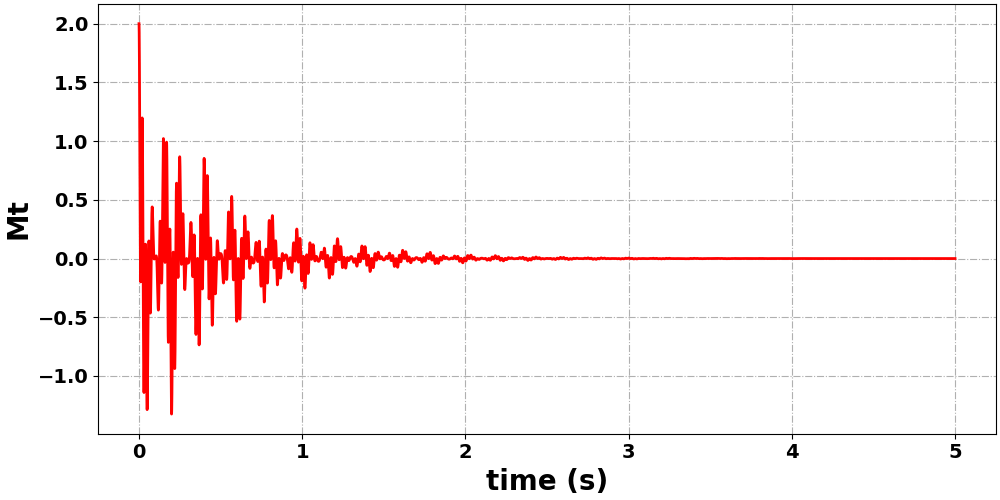

In [23]:
QS.Plotting.Plotting_SpanSelector(t,Mt,"time (s)","Mt","red") 

(<Figure size 1000x500 with 1 Axes>,
 <matplotlib.widgets.SpanSelector at 0x7c554b132d20>)

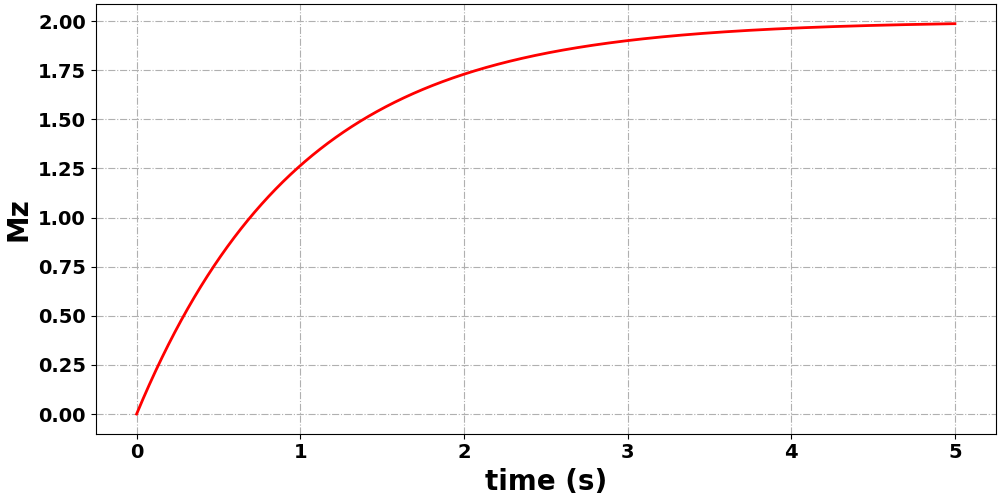

In [24]:
QS.Plotting.Plotting_SpanSelector(t,Mz,"time (s)","Mz","red") 

## Fourier Transform

In [25]:
freq, spectrum = QS.Spro.FourierTransform(Mt,QS.AcqFS,5)

(<Figure size 1000x500 with 1 Axes>,
 <matplotlib.widgets.SpanSelector at 0x7c55497c8e60>)

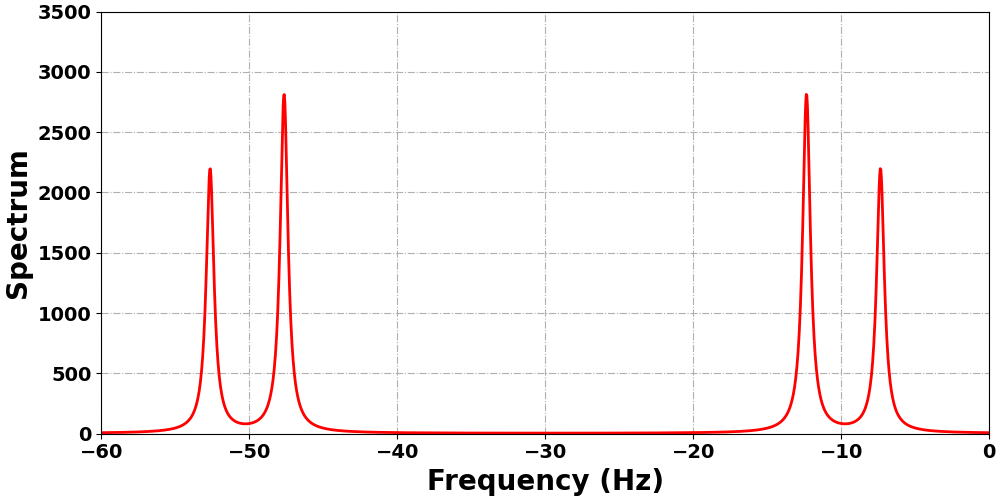

In [26]:
QS.Plotting.PlotXlimt= (-60,0)
QS.Plotting.PlotYlimt= (0,3500)
QS.Plotting.Plotting_SpanSelector(freq,spectrum,"Frequency (Hz)","Spectrum","red")